# Brownian Motion for Quantitative Finance

Important properties of brownian motion is that it is a martingale (Markov Process) and that it accumulates quadratic variation at rate one per unit time.

In [1]:
import math
import itertools
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

## Brownian Motion

A Brownian motion is a stochastic process {$W_{t}$}

Filtered probability space ($\Omega, {F_t}, P$)

$W: [0, T] X \Omega \rightarrow R$

1. $W_0 = 0$
2. $W$ has independent increments
3. $W$ has Gaussian (normal) increments
4. $W$ has continous sample paths (almost surely)

## Symmetric Random Walk

Picture you have successive coin tosses, $\omega = \omega_1\omega_2$\omega_3$... Where $\omega_n$ is the outcome of the $n^{th}$ toss.

We also have that for a R.V. $X_j$ it is +1 if we see H and -1 if we see T at time step $j$

If we define $M_0 = 0$

$M_k = \sum_{j=1}^{k} X_j$

In [2]:
# Init parameters
M = 10 # Number of simulations
t = 10 # time

In [3]:
random_walk = [-1, 1]
steps = np.random.choice(random_walk, size=(M, t)).T
origin = np.zeros((1, M))
rw_paths = np.concatenate([origin, steps]).cumsum(axis=0)

<function matplotlib.pyplot.show(close=None, block=None)>

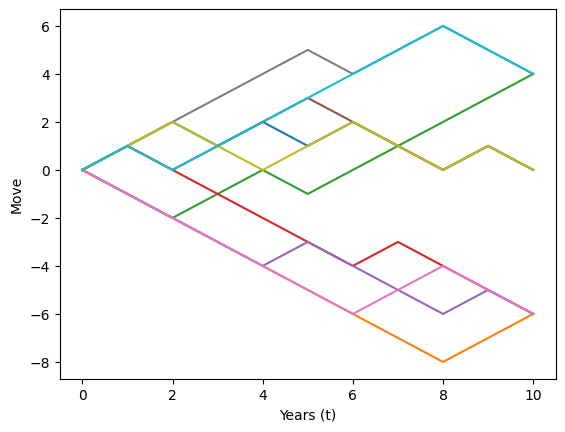

In [4]:
plt.plot(rw_paths)
plt.xlabel('Years (t)')
plt.ylabel('Move')
plt.show

### Properties of a Symmetric Random Walk

1. Independent Increments
2. Martingale
3. Quadratic Variation


In [5]:
# Create Quadratic variation and Variance functions
quad_var = lambda x: round(np.square(x[:-1] - x[1:]).sum(), 3)
var = lambda x: round(np.var(x, axis=0), 3)

In [6]:
[quad_var(path) for path in rw_paths.T[:4]]

[np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0)]

In [7]:
[var(path) for path in rw_paths[1:11]] 

[np.float64(0.96),
 np.float64(2.76),
 np.float64(4.04),
 np.float64(7.84),
 np.float64(11.24),
 np.float64(14.44),
 np.float64(15.84),
 np.float64(20.16),
 np.float64(18.24),
 np.float64(17.76)]

## Scaled Symmetric Random Walk

To approximate a Brownian Motion, we can speed up time and scale down the step size.

$W^{(n)}(t) = \frac{1}{\sqrt{n}}M_{nt}$

In [8]:
# Parameters
M = 10 # Number of simulations
t = 10 # time
n = 10

In [14]:
random_walk = [-1, 1]
steps = (1/np.sqrt(n)) * np.random.choice(random_walk, size=(M, t*n)).T
origin = np.zeros((1, M))
srw_paths = np.concatenate([origin, steps]).cumsum(axis=0)

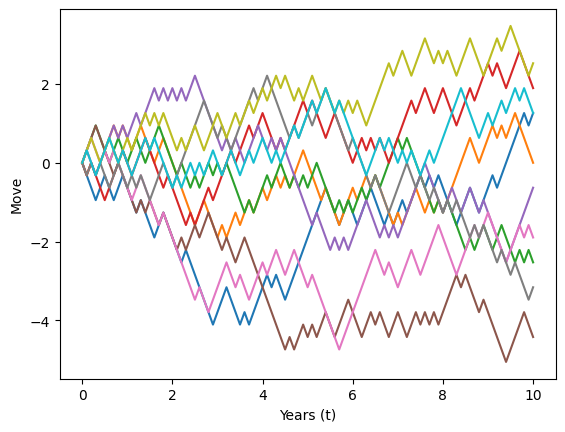

In [16]:
time = np.linspace(0, t, t*n+1)
tt = np.full(shape=(M, t*n+1), fill_value=time)
tt = tt.T

plt.plot(tt, srw_paths)
plt.xlabel('Years (t)')
plt.ylabel('Move')
plt.show()

In [17]:
[var(path) for path in srw_paths[1:11]]

[np.float64(0.096),
 np.float64(0.164),
 np.float64(0.34),
 np.float64(0.16),
 np.float64(0.176),
 np.float64(0.276),
 np.float64(0.324),
 np.float64(0.144),
 np.float64(0.224),
 np.float64(0.276)]

In [18]:
[quad_var(path) for path in srw_paths.T[:4]]

[np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0)]

## Limit of Binominal Distribution

As n increases, the binominal distribution converges to the normal distribution with variance t.

$W^{(n)}(t)=\frac{1}{\sqrt{n}}M_{nt}$

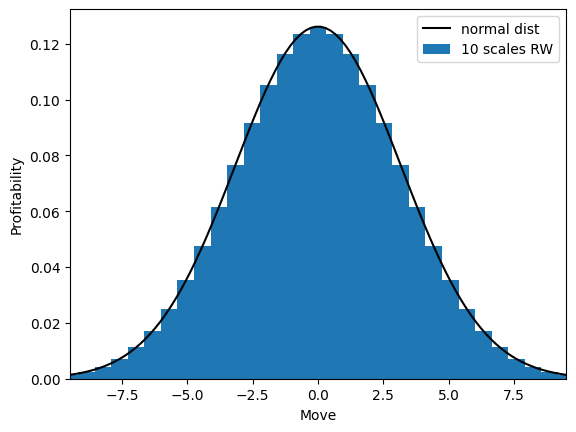

In [19]:
n = 10
t = 10

# Combinations
def nCr(n, k):
    f = math.factorial
    return f(n) / (f(k) * f(n-k))

perms = [nCr(n*t, k)*(0.5)**(n*t) for k in range(int(n*t)+1)]

W_nt = lambda n,t: 1/np.sqrt(n) * np.arange(-n*t, n*t+1, 2)

outcomes = W_nt(n, t)
plt.bar(outcomes, [perm/(outcomes[1]-outcomes[0]) for perm in perms], outcomes[1]-outcomes[0],
label='{0} scales RW'.format(n))

x = np.linspace(-3*np.sqrt(t), 3*np.sqrt(t), 100)
plt.plot(x, stats.norm.pdf(x, 0, np.sqrt(t)), 'k-', label='normal dist')

plt.xlim(-3*np.sqrt(t), 3*np.sqrt(t))
plt.ylabel('Profitability')
plt.xlabel('Move')
plt.legend()
plt.show()

## Brownian Motion Simulation

In [32]:
# Parameters
M = 100
t = 10
n = 100
dt = t/n # Time steps

In [33]:
steps = np.random.normal(0, np.sqrt(dt), size=(M, n)).T
origin = np.zeros((1, M))
bm_paths = np.concatenate([origin, steps]).cumsum(axis=0)

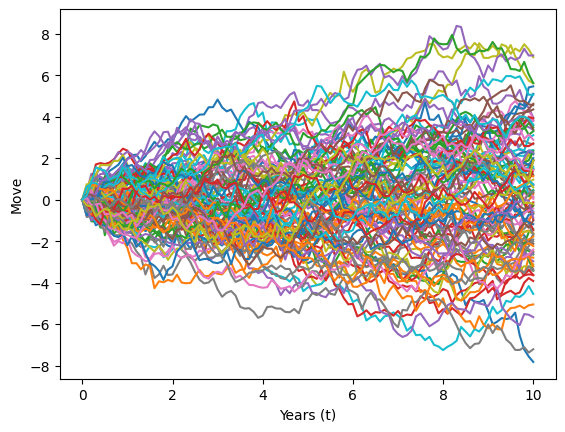

In [34]:
time = np.linspace(0, t, n+1)
tt = np.full(shape=(M, n+1), fill_value=time)
tt = tt.T

plt.plot(tt, bm_paths)
plt.xlabel('Years (t)')
plt.ylabel('Move')
plt.show()

In [35]:
[quad_var(path) for path in bm_paths.T[:4]]

[np.float64(10.081), np.float64(10.893), np.float64(8.661), np.float64(9.594)]

In [36]:
[var(path) for path in bm_paths[1:11]]

[np.float64(0.108),
 np.float64(0.232),
 np.float64(0.377),
 np.float64(0.46),
 np.float64(0.559),
 np.float64(0.623),
 np.float64(0.758),
 np.float64(0.891),
 np.float64(1.052),
 np.float64(1.078)]